# 01 — Exploratory Data Analysis

Understand class imbalance, feature distributions, and fraud vs. legit separation before any modelling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


Matplotlib is building the font cache; this may take a moment.


## 1. Load data

In [5]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
df.head(3)


Shape: (284807, 31)

Column dtypes:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## 2. Class imbalance

The central challenge: 0.172% fraud rate. Any model that always predicts 'not fraud' gets 99.83% accuracy and catches zero fraud.

Legit:    284,315
Fraud:    492
Ratio:    578:1
Fraud %:  0.1727%


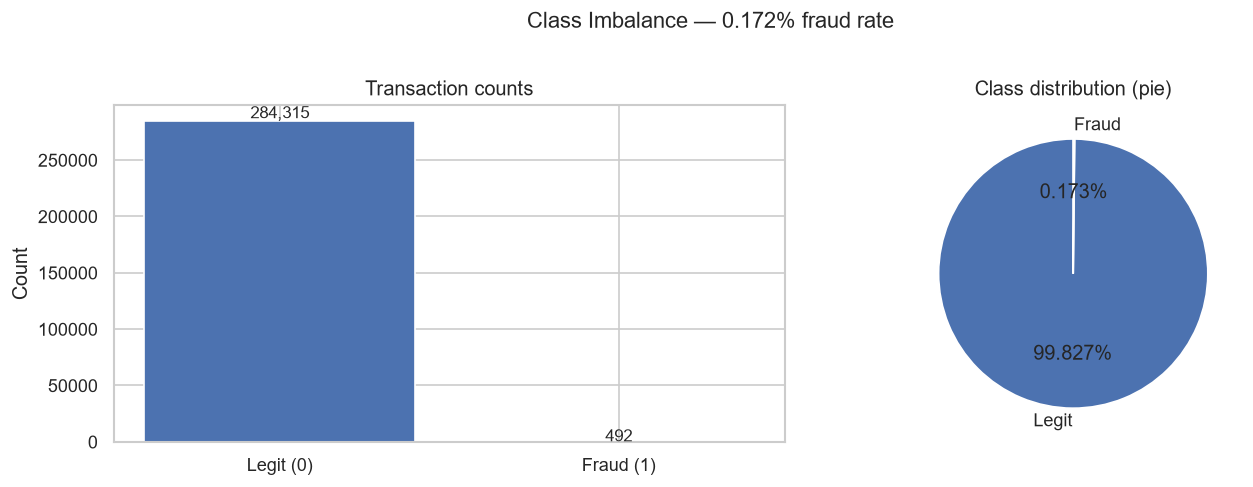

In [6]:
class_counts = df["Class"].value_counts()
fraud_rate   = df["Class"].mean()

print(f"Legit:    {class_counts[0]:,}")
print(f"Fraud:    {class_counts[1]:,}")
print(f"Ratio:    {class_counts[0]/class_counts[1]:.0f}:1")
print(f"Fraud %:  {fraud_rate:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
axes[0].bar(["Legit (0)", "Fraud (1)"], class_counts.values, color=["#4C72B0", "#DD8452"])
axes[0].set_title("Transaction counts", fontsize=12)
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"{val:,}", ha="center", fontsize=10)

# Pie
axes[1].pie(class_counts.values, labels=["Legit", "Fraud"],
            autopct="%1.3f%%", colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Class distribution (pie)", fontsize=12)

plt.suptitle("Class Imbalance — 0.172% fraud rate", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3. Amount distribution — fraud vs. legit

ModuleNotFoundError: No module named 'scipy'

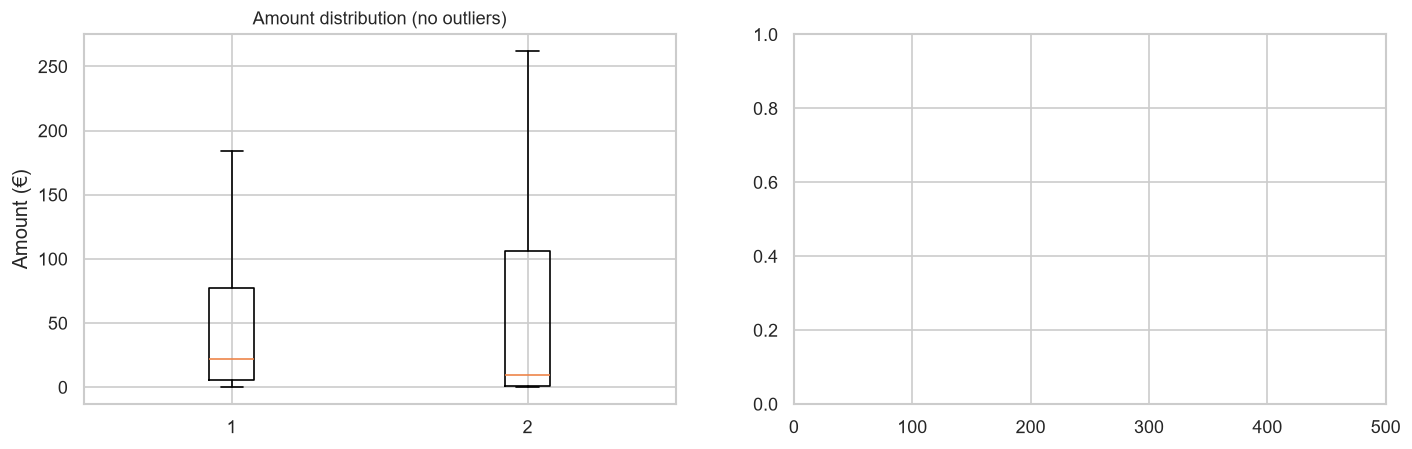

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

legit = df[df["Class"] == 0]["Amount"]
fraud = df[df["Class"] == 1]["Amount"]

# Box plot
data_to_plot = [legit, fraud]
axes[0].boxplot(data_to_plot, label=["Legit", "Fraud"], showfliers=False)
axes[0].set_title("Amount distribution (no outliers)", fontsize=11)
axes[0].set_ylabel("Amount (€)")

# KDE
axes[1].set_xlim(0, 500)
legit.clip(upper=500).plot.kde(ax=axes[1], label="Legit", color="#4C72B0", bw_method=0.3)
fraud.clip(upper=500).plot.kde(ax=axes[1], label="Fraud", color="#DD8452", bw_method=0.3)
axes[1].set_title("Amount KDE (clipped at €500)", fontsize=11)
axes[1].set_xlabel("Amount (€)")
axes[1].legend()

plt.suptitle("Transaction Amount — Legit vs. Fraud", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nLegit  — median: €{legit.median():.2f}  |  mean: €{legit.mean():.2f}  |  max: €{legit.max():.2f}")
print(f"Fraud  — median: €{fraud.median():.2f}  |  mean: €{fraud.mean():.2f}  |  max: €{fraud.max():.2f}")


## 4. Time distribution — when does fraud happen?

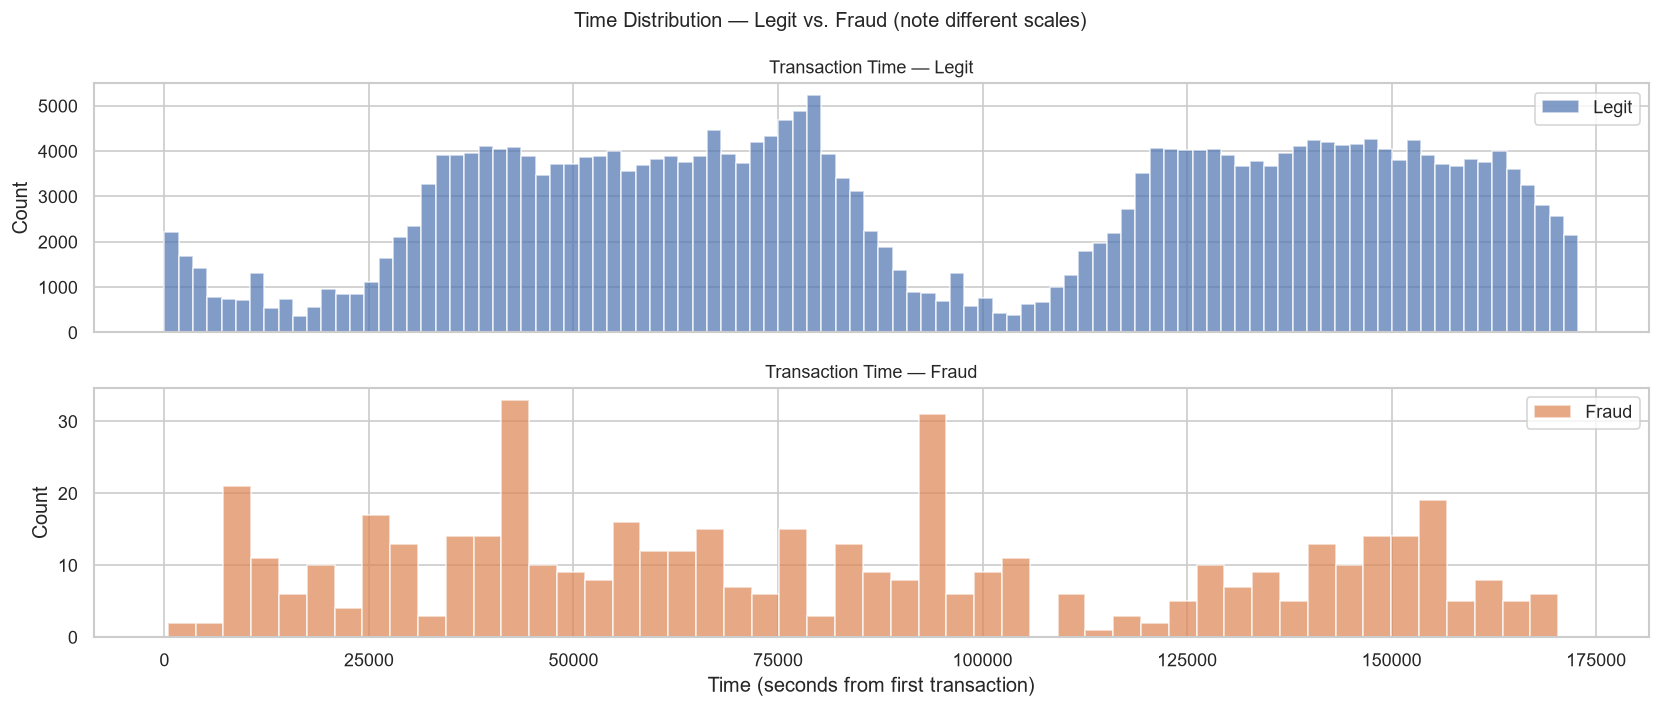

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

bins = np.linspace(0, df["Time"].max(), 100)
axes[0].hist(df[df["Class"]==0]["Time"], bins=bins, alpha=0.7, color="#4C72B0", label="Legit")
axes[0].set_title("Transaction Time — Legit", fontsize=11)
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(df[df["Class"]==1]["Time"], bins=50, alpha=0.7, color="#DD8452", label="Fraud")
axes[1].set_title("Transaction Time — Fraud", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Time (seconds from first transaction)")
axes[1].legend()

plt.suptitle("Time Distribution — Legit vs. Fraud (note different scales)", fontsize=12)
plt.tight_layout()
plt.show()


## 5. V-feature distributions — where fraud separates from legit

V1–V28 are PCA-anonymised. We plot the features with the highest mean-difference between classes, because these are where a model can most easily separate fraud from legit.

Top 8 discriminative V-features: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4']


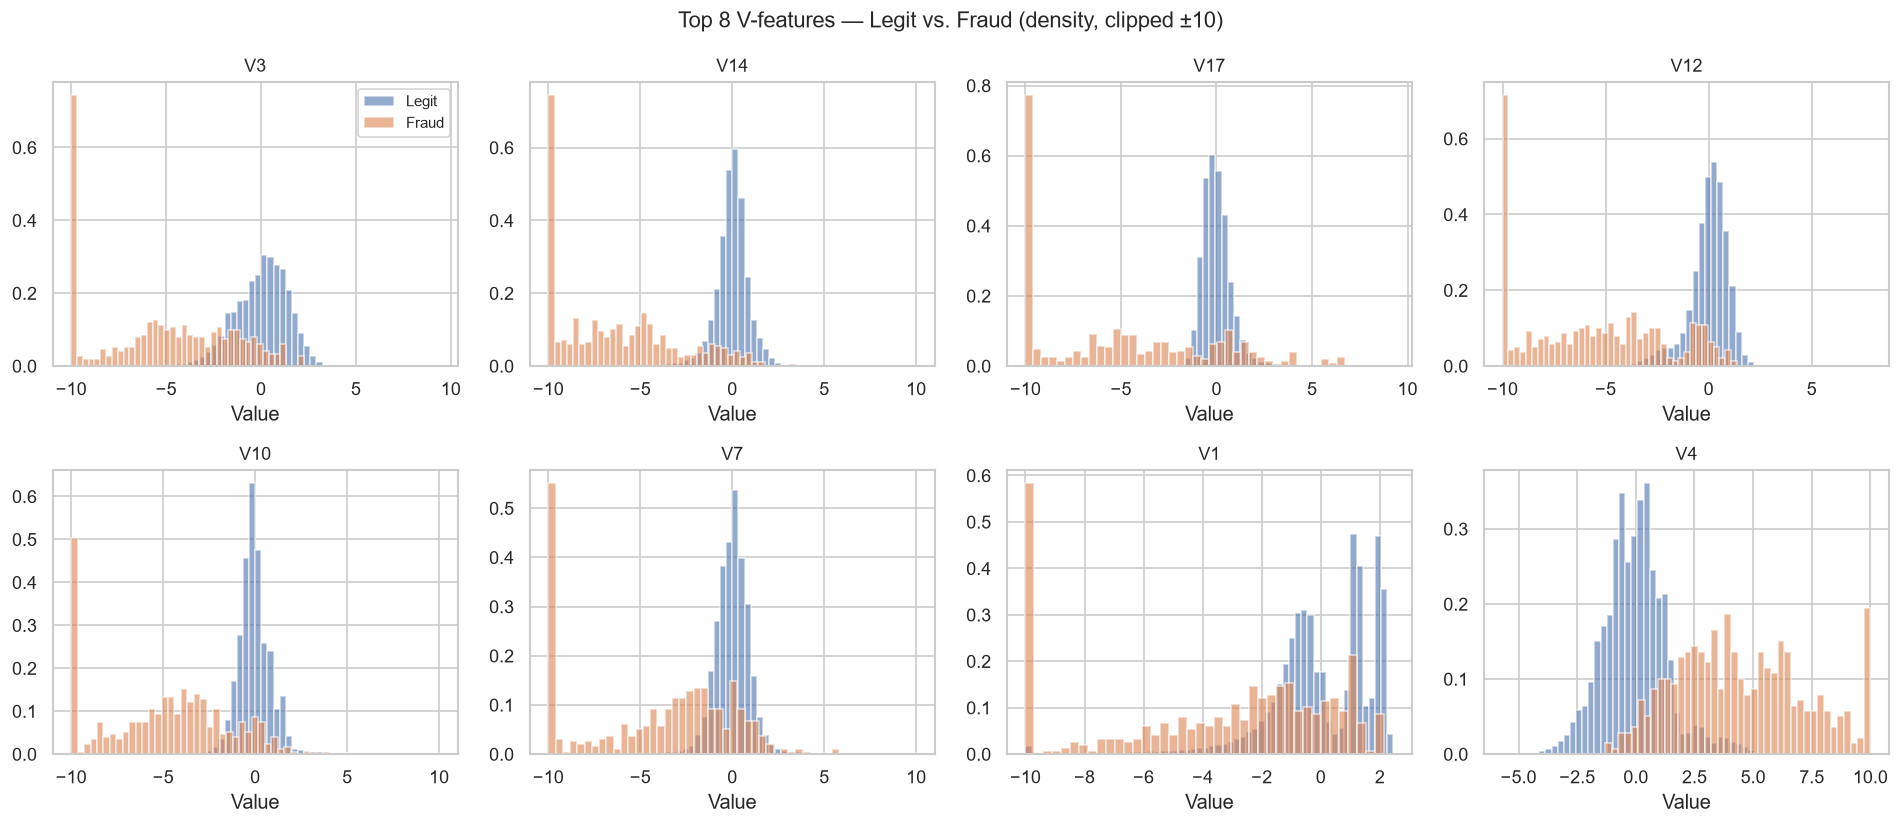

In [10]:
# Compute mean absolute difference per V-feature
v_cols = [f"V{i}" for i in range(1, 29)]
diff = (df[df["Class"]==1][v_cols].mean() - df[df["Class"]==0][v_cols].mean()).abs()
top_v = diff.nlargest(8).index.tolist()
print("Top 8 discriminative V-features:", top_v)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, feat in zip(axes, top_v):
    ax.hist(df[df["Class"]==0][feat].clip(-10, 10), bins=60,
            alpha=0.6, color="#4C72B0", label="Legit", density=True)
    ax.hist(df[df["Class"]==1][feat].clip(-10, 10), bins=40,
            alpha=0.6, color="#DD8452", label="Fraud", density=True)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel("Value")
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle("Top 8 V-features — Legit vs. Fraud (density, clipped ±10)", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Correlation heatmap (V-features)

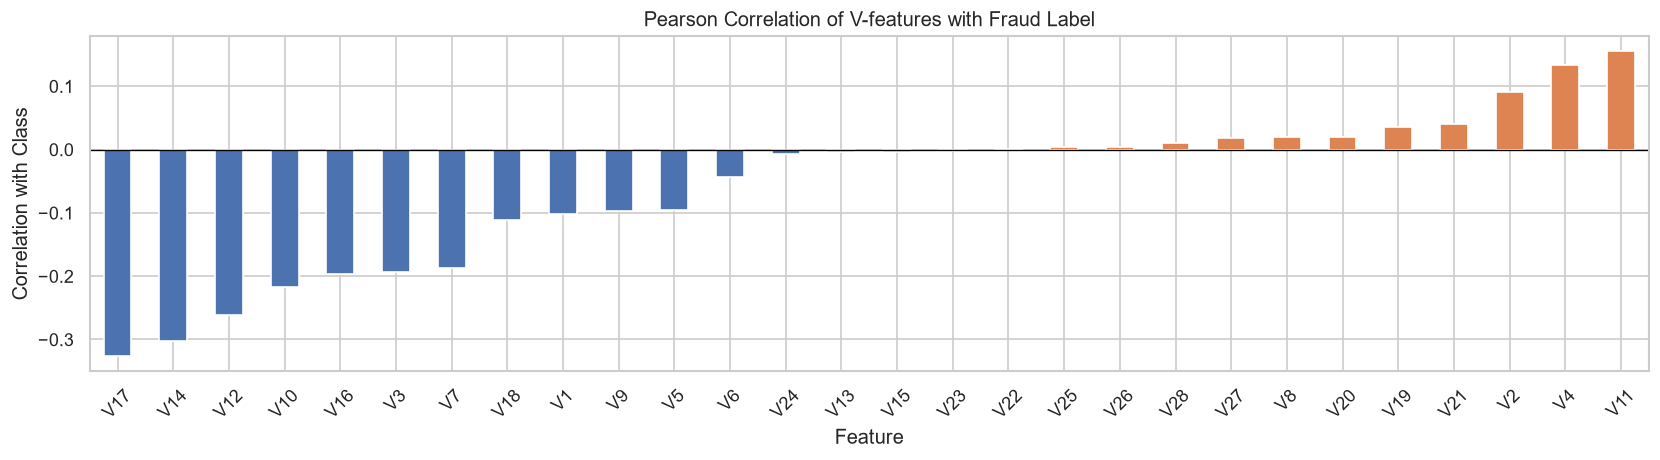


Most positively correlated with fraud:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876

Most negatively correlated with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539


In [11]:
corr = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()

plt.figure(figsize=(14, 4))
corr.plot(kind="bar", color=["#DD8452" if v > 0 else "#4C72B0" for v in corr])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Pearson Correlation of V-features with Fraud Label", fontsize=12)
plt.xlabel("Feature")
plt.ylabel("Correlation with Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMost positively correlated with fraud:")
print(corr.tail(5).to_string())
print("\nMost negatively correlated with fraud:")
print(corr.head(5).to_string())


## 7. Key EDA takeaways

| Finding | Implication for pipeline |
|---------|-------------------------|
| 0.172% fraud rate | Must use AUC-PR, not AUC-ROC; must handle imbalance |
| Fraud transactions cluster at night | Cyclical time encoding captures this pattern |
| V14, V12, V10, V4, V11 most discriminative | Pairwise interactions of these features are valuable |
| Fraud amounts not dramatically higher | Amount alone is not a strong signal — feature interactions matter |